In [1]:
import os
cwd = os.getcwd().split("/")[:-1]
cwd = "/".join(cwd)
os.chdir(cwd)
print(cwd)

import cobra
from cobra.flux_analysis import flux_variability_analysis
from labutils.mycobra.sparse import find_leaks

/opt/asaldivar/projects/h_lacustris


In [6]:
import plotly.express as px

In [10]:
model_file = "models/draft/v0.0.1/hlacustris.xml"
model = cobra.io.read_sbml_model(model_file)
sol = model.optimize()
model.summary(solution=sol)

Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,156.1,1,100.00%
h2o_e,EX_h2o_e,126.5,0,0.00%
h_e,EX_h_e,0.5801,0,0.00%
mg2_e,EX_mg2_e,0.01338,0,0.00%
no3_e,EX_no3_e,1.362,0,0.00%
o2_e,EX_o2_e,1.188,0,0.00%
photonVis_e,EX_photonVis_e,1000,0,0.00%
pi_e,EX_pi_e,0.5083,0,0.00%
so4_e,EX_so4_e,0.0718,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux


In [27]:
num_tol = 1e-6
fva_sol = flux_variability_analysis(model)
non_zero_mask = [abs(row["minimum"]) > num_tol and abs(row["maximum"] > num_tol) for i, row in fva_sol.iterrows()]
print(f"{sum(non_zero_mask)} reactions have flux")

486 reactions have flux


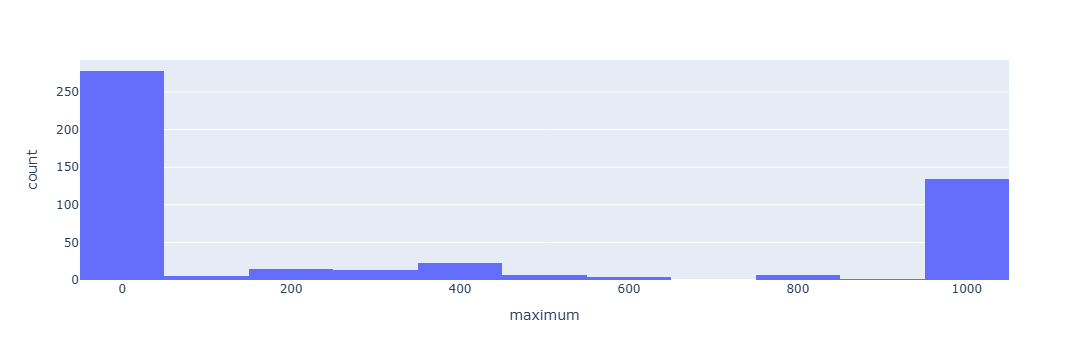

In [28]:
px.histogram(fva_sol[non_zero_mask], x="maximum")